In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 33.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

✅ Best model loaded successfully.

image 1/1 /content/002088.jpg: 384x640 1 cow, 391.4ms
Speed: 26.2ms preprocess, 391.4ms inference, 35.5ms postprocess per image at shape (1, 3, 384, 640)


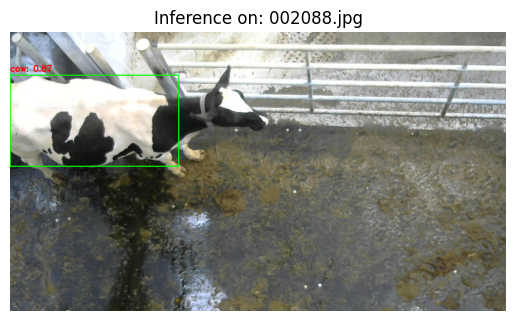

✅ Saved: /content/drive/MyDrive/MooNet Datasets/Cow_Detection_Dataset/Cow_Data/inference_results/002088.jpg


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


# ============ CONFIG ============
# لازم تعرف base_dir
base_dir = "/content/drive/MyDrive/MooNet Datasets/Cow_Detection_Dataset/Cow_Data"
best_model_path = os.path.join(base_dir, 'runs', 'yolov8-cow-detection', 'weights', 'best.pt')

if os.path.exists(best_model_path):
    model = YOLO(best_model_path)
    print("✅ Best model loaded successfully.")
else:
    raise FileNotFoundError("❌ Best model not found.")

# ============ OUTPUT ============
output_dir = os.path.join(base_dir, "inference_results")
os.makedirs(output_dir, exist_ok=True)

# ============ INFERENCE FUNCTION ============
def infer_on_image(image_path):
    if not os.path.exists(image_path):
        print(f"❌ Image not found: {image_path}")
        return

    # Run inference
    results = model(image_path)[0]

    # Read image
    image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

    # Check if any boxes were detected
    if results.boxes is None or len(results.boxes) == 0:
        print("⚠️ No objects detected.")
        return

    # Draw detections
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        confidence = float(box.conf[0])
        label = f"cow: {confidence:.2f}"
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    # Show image
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Inference on: {os.path.basename(image_path)}")
    plt.show()

    # Save output
    output_path = os.path.join(output_dir, os.path.basename(image_path))
    cv2.imwrite(output_path, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
    print(f"✅ Saved: {output_path}")

# ============ USAGE ============
image_path = "/content/002088.jpg"
infer_on_image(image_path)
